# Task 2: Product Category Clustering

**Goal:** group the Amazon products into a small number of meaningful **meta-categories**, using the `categories` field, and compare two clustering models.

**Approach:**
1. Load and combine all three review files, then remove reviews that appear in more than one file.
2. Build a **product table**: one row per product `id`. All reviews of a product share the same categories, so clustering ~92 products instead of ~50k reviews gives the same result and is much faster.
3. Clean the `categories` tags: split them correctly, drop store/marketing noise and normalize spelling variants.
4. Build a **vocabulary from the categories** and turn each product into a **TF-IDF** vector. The product `name` is projected onto that same vocabulary as a weaker, secondary signal.
5. Reduce the vectors with **LSA** (TruncatedSVD) so synonyms like *ereader* / *ebook* / *kindle* end up close together.
6. Cluster with two models, **K-Means** and **Agglomerative (Ward)**, choosing *k* with silhouette and Davies-Bouldin scores.
7. Name the clusters, compare the two models (internal scores, agreement, stability) and label every review.

# 1. Load the data

All three files have the same review schema (`id`, `name`, `categories`, `reviews.*`). A `source` column keeps track of where each row came from.

In [3]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 100)

# The three source files (listed explicitly so the output file saved in section 11 is never read back in)
files = [
    "datasets/1429_1.csv",
    "datasets/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv",
    "datasets/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv",
]
raw = pd.concat(
    [pd.read_csv(f, low_memory=False).assign(source=os.path.basename(f)) for f in files],
    ignore_index=True,
)

display(raw.groupby("source").agg(rows=("id", "size"), products=("id", "nunique")))
print("Combined:", raw.shape)

,rows,products
source,,
1429_1.csv,34660,42
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv,5000,24
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv,28332,65


Combined: (67992, 28)


In [4]:
# The files overlap: the same review can appear in several of them.
# A review is identified by product id + username + review text.
review_key = ["id", "reviews.username", "reviews.text"]
print("Duplicate reviews across files:", raw.duplicated(review_key).sum())

reviews = raw.drop_duplicates(review_key).reset_index(drop=True)
print("Unique reviews:", len(reviews))
print("Unique products (id):", reviews["id"].nunique())

Duplicate reviews across files: 7151
Unique reviews: 60841
Unique products (id): 92


# 2. Product table

The clustering is based on `categories`, which is a property of the **product**, not of the review. Clustering one row per product:
- gives every product the same weight (a product with 10,000 reviews doesn't dominate a product with 5),
- is fast and lets us use any algorithm, including agglomerative clustering, which needs all pairwise distances,
- gives every review of a product the same category.

Some products have slightly different `categories` strings in different files, so all their tags are merged. Names are cleaned (some have a duplicated copy after a line break and trailing commas) and the most common name is kept. 9 products have no name in any file.

In [5]:
def split_tags(categories):
    # Tags are separated by "," with no space; "," followed by a space is part of a tag
    # (e.g. "Smart Speakers, Hubs & Accessories")
    return [t.strip() for t in re.split(r",(?! )", str(categories)) if t.strip()]

def clean_name(names):
    names = names.dropna().str.split("\r\n").str[0].str.rstrip(",").str.strip()
    return names.mode().iloc[0] if len(names) else ""

products = reviews.groupby("id").agg(
    name=("name", clean_name),
    raw_tags=("categories", lambda s: sorted({t for c in s.dropna().unique() for t in split_tags(c)})),
    n_reviews=("id", "size"),
)
print(products.shape)
display(products.sample(5, random_state=1))

(92, 3)


,name,raw_tags,n_reviews
id,,,
AVqkIdZiv8e3D1O-leaJ,"Fire Tablet with Alexa, 7 Display, 16 GB, Magenta - with Special Offers","[All Tablets, Amazon Tablets, Android Tablets, Computers & Tablets, Electronics, Fire Tablets, T...",764
AVzYlGj3vKc47QAVeZRH,"Amazon Fire HD 8 with Alexa (8"" HD Display Tablet)","[All Tablets, Amazon, Amazon Tablets, Computers & Tablets, Computers/Tablets & Networking, Elect...",130
AVphgVaX1cnluZ0-DR74,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta","[All Tablets, Android Tablets, Computers & Tablets, Electronics, Electronics, Tech Toys, Movies,...",10966
AVqVGZQBQMlgsOJE6eUb,"Kindle Oasis E-reader with Leather Charging Cover - Walnut, 6 High-Resolution Display (300 ppi),...","[Amazon Book Reader, Amazon Ereaders, Computers & Tablets, E-Readers, E-Readers & Accessories, E...",62
AVzYlGkFvKc47QAVeZRI,"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Marine Blue - with Special Offers","[All Tablets, Amazon Tablets, Computers & Tablets, Fire Tablets, Tablets]",882


# 3. Clean the categories

The tags contain a lot of noise that says nothing about the product type:
- **"See more …"** tags, which are truncated product names
- **store and marketing tags:** *Frys*, *Walmart for Business*, *Featured Brands*, *Holiday Shop*, *Amazon SMP*, …
- **internal codes:** *Digital Device 3*, *14701001*, *mazon.co.uk*, *TVs Entertainment xbqxrzdteyyb*

These are removed. The remaining text is then normalized:
- spelling variants are unified: *eBook Readers*, *E-Readers*, *Ereaders* → `ereader`; *iPad* → `tablet`
- stop words, numbers and brand words (*amazon*) are removed
- a light stemmer turns plurals into singular (*tablets* → *tablet*, *accessories* → *accessory*)

In [6]:
from collections import Counter

tag_counts = Counter(t for tags in products["raw_tags"] for t in tags)
print(f"{len(tag_counts)} distinct tags. Most common (number of products):")
display(pd.Series(dict(tag_counts.most_common(25))))

334 distinct tags. Most common (number of products):


Electronics                       58
Computers & Tablets               35
Tablets                           31
All Tablets                       24
Fire Tablets                      24
Electronics Features              23
Computers/Tablets & Networking    19
Amazon Tablets                    19
Amazon                            17
Consumer Electronics              16
Kindle Store                      15
Amazon Devices                    14
Amazon Device Accessories         14
iPad & Tablets                    12
Amazon Echo                       12
Kindle E-readers                  11
Tablets & eBook Readers           11
Amazon Home                       11
Digital Device 3                  11
E-Readers & Accessories           10
Featured Brands                   10
Computers & Accessories           10
Amazon Book Reader                 9
Amazon Ereaders                    9
eBook Readers                      9
dtype: int64

In [7]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

NOISE_TAGS = {
    "amazon", "amazonbasics", "frys", "walmart for business", "featured brands", "holiday shop",
    "amazon smp", "electronics features", "computers features", "ways to shop", "on to college",
    "electronics deals", "amazon devices", "amazon home", "home improvement",
}
BRAND_WORDS = {"amazon", "mazon", "uk", "com"}

# Spelling variants -> one token
SYNONYMS = [
    (r"\be[\s-]?books?\b", "ebook"),
    (r"\be[\s-]?readers?\b|\bbook readers?\b", "ereader"),
    (r"\bipads?\b", "tablet"),
    (r"\btvs\b", "tv"),
    (r"\baccs\b", "accessories"),
]

def clean_tag(tag):
    # Return the tag in lowercase, or None if it is noise
    t = tag.lower()
    if t.startswith("see more") or t in NOISE_TAGS or t.startswith("digital device"):
        return None
    if re.fullmatch(r"[\d\s]+", t) or "." in t:              # numeric codes, domains like "mazon.co.uk"
        return None
    t = re.sub(r"\b[a-z]*[bcdfghjklmnpqrstvwxz]{6,}[a-z]*\b", " ", t)   # junk like "xbqxrzdteyyb"
    t = re.sub(r"\(.*?\)", " ", t)                           # "(5th Generation)"
    return t

def normalize_text(text):
    t = re.sub(r"[^a-z0-9\s]", " ", text.lower())
    for pattern, replacement in SYNONYMS:
        t = re.sub(pattern, replacement, t)
    words = []
    for w in t.split():
        if w in ENGLISH_STOP_WORDS or w in BRAND_WORDS or len(w) < 2 or w.isdigit():
            continue
        if w.endswith("ies") and len(w) > 4:                 # accessories -> accessory
            w = w[:-3] + "y"
        elif w.endswith("s") and not w.endswith("ss") and len(w) > 3:   # tablets -> tablet
            w = w[:-1]
        words.append(w)
    return " ".join(words)

def categories_to_text(tags):
    # One cleaned document per product; " | " keeps tags apart so bigrams don't cross tags
    cleaned = (clean_tag(t) for t in tags)
    return " | ".join(normalize_text(t) for t in cleaned if t)

products["cat_text"] = products["raw_tags"].apply(categories_to_text)
products["name_text"] = products["name"].apply(normalize_text)

# Before / after for one product
example = products.iloc[0]
print("RAW TAGS:", example["raw_tags"])
print("\nCLEANED :", example["cat_text"])

RAW TAGS: ['Amazon Book Reader', 'Amazon Devices', 'Amazon Ereaders', 'Computers & Tablets', 'E-Readers', 'E-Readers & Accessories', 'EBook Readers', 'Electronics', 'Featured Brands', 'Kindle E-readers', 'Tablets', 'Tablets & E-Readers']

CLEANED : ereader | ereader | computer tablet | ereader | ereader accessory | ebook reader | electronic | kindle ereader | tablet | tablet ereader


**Products with no useful tags.** If nothing is left after cleaning, the product borrows the tags of the product with **exactly the same name** that has the most reviews.

Only one same-name product is used because `name` is not reliable, especially in `1429_1.csv`: the name *"Fire Tablet, 7 Display, Wi-Fi, 8 GB … Black"* is attached to 7 different ids, including a Kindle Voyage and a power adapter. The listing with the most reviews is the most likely to be the real product. This is also why `name` is only a secondary signal in the features.

In [8]:
has_tags = products["cat_text"].str.strip() != ""
tags_by_name = (products[has_tags & (products["name"] != "")]
                .sort_values("n_reviews", ascending=False)
                .drop_duplicates("name")                  # most-reviewed product per name
                .set_index("name")["raw_tags"])

missing = ~has_tags
print("Products with no useful tags:", products.loc[missing, "name"].tolist())

borrow = missing & products["name"].isin(tags_by_name.index)
products.loc[borrow, "raw_tags"] = products.loc[borrow, "name"].map(tags_by_name)
products.loc[borrow, "cat_text"] = products.loc[borrow, "raw_tags"].apply(categories_to_text)
print("Borrowed tags from a same-name product:", borrow.sum())

Products with no useful tags: ['Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black']
Borrowed tags from a same-name product: 1


# 4. Vocabulary and TF-IDF features

`TfidfVectorizer` builds the vocabulary **from the cleaned categories only**:
- **unigrams and bigrams** (`ngram_range=(1, 2)`) so phrases like *smart home*, *fire tv*, *power adapter* become features
- `min_df=2`: a term must appear in at least 2 products, otherwise it can't help group products together
- `max_df=0.6`: terms in more than 60% of products (e.g. *electronic*) don't separate anything and are dropped
- `sublinear_tf=True` dampens terms repeated in many tags of the same product

**Using `name`:** the name is transformed with the **same category vocabulary** and added with a weight of 0.5. It can only reinforce category terms (e.g. *kindle*, *tablet*, *echo*), not add new ones. This matters for products with almost no useful tags, like the Fire Tablet whose only categories are *Amazon Devices* and *mazon.co.uk*.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

NAME_WEIGHT = 0.5

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.6, sublinear_tf=True, token_pattern=r"[a-z0-9]+"
)
vectorizer.fit(products["cat_text"])            # vocabulary from categories only
vocabulary = vectorizer.get_feature_names_out()
print("Vocabulary size:", len(vocabulary))
print("Sample:", ", ".join(vocabulary[::25]))

X_cat = vectorizer.transform(products["cat_text"])
X_name = vectorizer.transform(products["name_text"])
X_tfidf = normalize(X_cat + NAME_WEIGHT * X_name)   # L2-normalize so cosine = dot product

empty_cat = np.asarray(X_cat.sum(axis=1)).ravel() == 0
print("\nProducts with no category features:", empty_cat.sum(), products.loc[empty_cat, "name"].tolist())
print("Products with no features at all after adding name:", (np.asarray(X_tfidf.sum(axis=1)).ravel() == 0).sum())

Vocabulary size: 389
Sample: aa, accessory tv, automation home, cable computer, charger camcorder, desktop accessory, electronic home, game, home smart, kit, networking electronic, photo, security home, store power, tablet networking, video audio

Products with no category features: 0 []
Products with no features at all after adding name: 0


# 5. Dimensionality reduction (LSA)

The TF-IDF matrix has hundreds of sparse, partly redundant columns (*ereader*, *ebook reader*, *kindle ereader* …). **Latent Semantic Analysis** (`TruncatedSVD`) compresses them into a few dense components that capture which terms appear together. This:
- merges synonyms and related terms into the same direction,
- removes noise from rare tag combinations,
- makes Euclidean distance (used by K-Means and Ward) behave well, because the vectors are re-normalized afterwards.

With only ~92 products, **10 components** keep the main structure without overfitting to individual products.

In [10]:
from sklearn.decomposition import TruncatedSVD

N_COMPONENTS = 10
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X = normalize(svd.fit_transform(X_tfidf))      # unit length -> Euclidean distance tracks cosine distance

print(f"Explained variance with {N_COMPONENTS} components: {svd.explained_variance_ratio_.sum():.1%}")

# What each component represents: its strongest terms
for i, comp in enumerate(svd.components_[:6]):
    print(f"Component {i}:", ", ".join(vocabulary[comp.argsort()[::-1][:6]]))

Explained variance with 10 components: 55.1%
Component 0: tablet, display, tablet tablet, tablet computer, computer tablet, computer
Component 1: kindle, ereader, accessory, accessory kindle, kindle ereader, cover
Component 2: echo, smart, speaker, home, assistant, hub
Component 3: ereader, ereader ereader, tablet ereader, ereader computer, kindle ereader, display
Component 4: streaming, media, streaming media, media player, tv, player
Component 5: laptop, case, kid, bag, accessory, crate


# 6. Choosing the number of clusters

Both models are fitted for k = 3 to 10 and scored on the same features:
- **Silhouette** (cosine): how well each product fits its own cluster compared to the nearest other cluster. Range −1 to 1, **higher is better**.
- **Davies-Bouldin**: average similarity between each cluster and its closest neighbour. **Lower is better**.
- **ARI** between the two models: 1.0 means both models produce the same grouping.

,KMeans silhouette,Agglo silhouette,KMeans DB,Agglo DB,ARI KMeans vs Agglo,KMeans smallest cluster
k,,,,,,
3,0.405,0.394,1.593,1.621,0.935,28
4,0.474,0.461,1.473,1.469,0.940,13
5,0.532,0.525,1.280,1.307,0.892,12
6,0.607,0.596,1.130,1.148,0.868,7
7,0.644,0.634,0.960,0.988,0.875,7
8,0.694,0.678,0.869,0.917,0.938,4
9,0.741,0.723,0.662,0.701,0.968,3
10,0.741,0.709,0.650,0.714,0.934,3


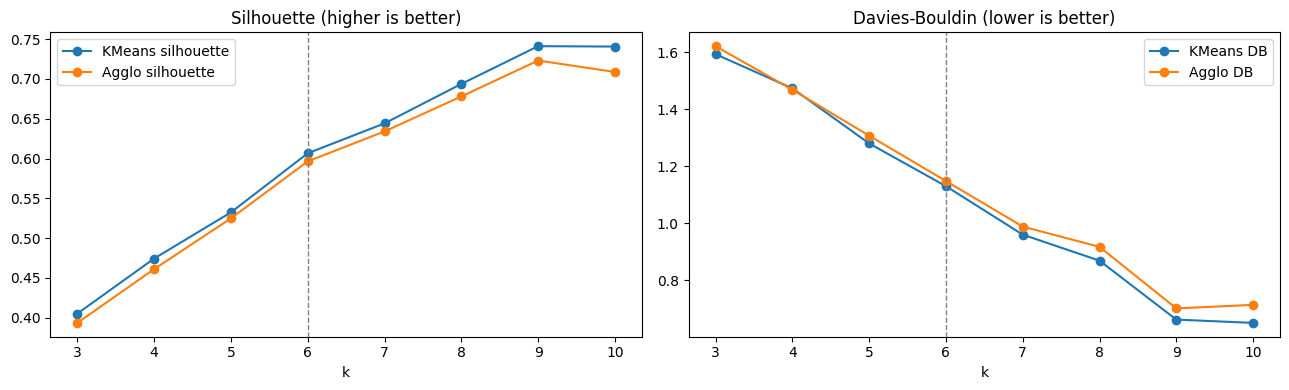

In [11]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
)

rows = []
for k in range(3, 11):
    km_labels = KMeans(n_clusters=k, n_init=50, random_state=42).fit_predict(X)
    ag_labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    rows.append({
        "k": k,
        "KMeans silhouette": silhouette_score(X, km_labels, metric="cosine"),
        "Agglo silhouette": silhouette_score(X, ag_labels, metric="cosine"),
        "KMeans DB": davies_bouldin_score(X, km_labels),
        "Agglo DB": davies_bouldin_score(X, ag_labels),
        "ARI KMeans vs Agglo": adjusted_rand_score(km_labels, ag_labels),
        "KMeans smallest cluster": np.bincount(km_labels).min(),
    })
k_scores = pd.DataFrame(rows).set_index("k")
display(k_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
k_scores[["KMeans silhouette", "Agglo silhouette"]].plot(ax=axes[0], marker="o", title="Silhouette (higher is better)")
k_scores[["KMeans DB", "Agglo DB"]].plot(ax=axes[1], marker="o", title="Davies-Bouldin (lower is better)")
for ax in axes:
    ax.axvline(6, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()

**Choosing k = 6**

- Both scores keep improving as *k* grows: silhouette rises from 0.41 (k = 3) to 0.74 (k = 9–10), and Davies-Bouldin falls. With only 92 products, more clusters always fit tighter, so the scores alone have no clear optimum.
- The goal is a **small set of meta-categories (4–6)**. Within that range, **k = 6 has the best silhouette (0.61) and the lowest Davies-Bouldin (1.13)** for both models.
- At k = 6 the smallest cluster still has 7 products. From k = 8 on, clusters shrink to 3–4 products, too small to be useful as categories.
- The two models agree strongly at k = 6 (ARI 0.87), a sign that the grouping is a real structure in the data and not an artifact of one algorithm.

In [12]:
BEST_K = 6

# 7. Model 1: K-Means

K-Means places *k* centers and assigns each product to the closest one, minimizing the within-cluster variance. `n_init=50` runs it 50 times from different random starts and keeps the best result, which matters with this few points.

In [13]:
kmeans = KMeans(n_clusters=BEST_K, n_init=50, random_state=42)
products["kmeans_cluster"] = kmeans.fit_predict(X)
display(products["kmeans_cluster"].value_counts().sort_index().rename("products"))

kmeans_cluster
0    27
1    18
2    15
3    12
4    13
5     7
Name: products, dtype: int64

# 8. Model 2: Agglomerative clustering

Agglomerative clustering starts with every product as its own cluster and repeatedly merges the two closest clusters. The **linkage** decides what "closest" means. The table compares the options at k = 6:
- **ward**: merges the pair that increases within-cluster variance the least
- **average / complete**: mean / maximum cosine distance between the members of two clusters

In [14]:
linkage_rows = []
for linkage_name, metric in [("ward", "euclidean"), ("average", "cosine"), ("complete", "cosine")]:
    labels = AgglomerativeClustering(n_clusters=BEST_K, linkage=linkage_name, metric=metric).fit_predict(X)
    linkage_rows.append({
        "linkage": linkage_name,
        "silhouette": silhouette_score(X, labels, metric="cosine"),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "cluster sizes": sorted(np.bincount(labels).tolist(), reverse=True),
    })
display(pd.DataFrame(linkage_rows).set_index("linkage").round(3))

,silhouette,Davies-Bouldin,cluster sizes
linkage,,,
ward,0.596,1.148,"[27, 20, 15, 12, 11, 7]"
average,0.533,0.862,"[58, 12, 8, 7, 4, 3]"
complete,0.469,1.380,"[34, 20, 15, 13, 7, 3]"


**Ward linkage is used.** It has the best silhouette (0.60) and balanced clusters. Average linkage has a lower Davies-Bouldin score but puts 58 of the 92 products into one giant cluster, which is useless as a category. Complete linkage scores worst on silhouette.

agglo_cluster
0    15
1    27
2    20
3    12
4    11
5     7
Name: products, dtype: int64

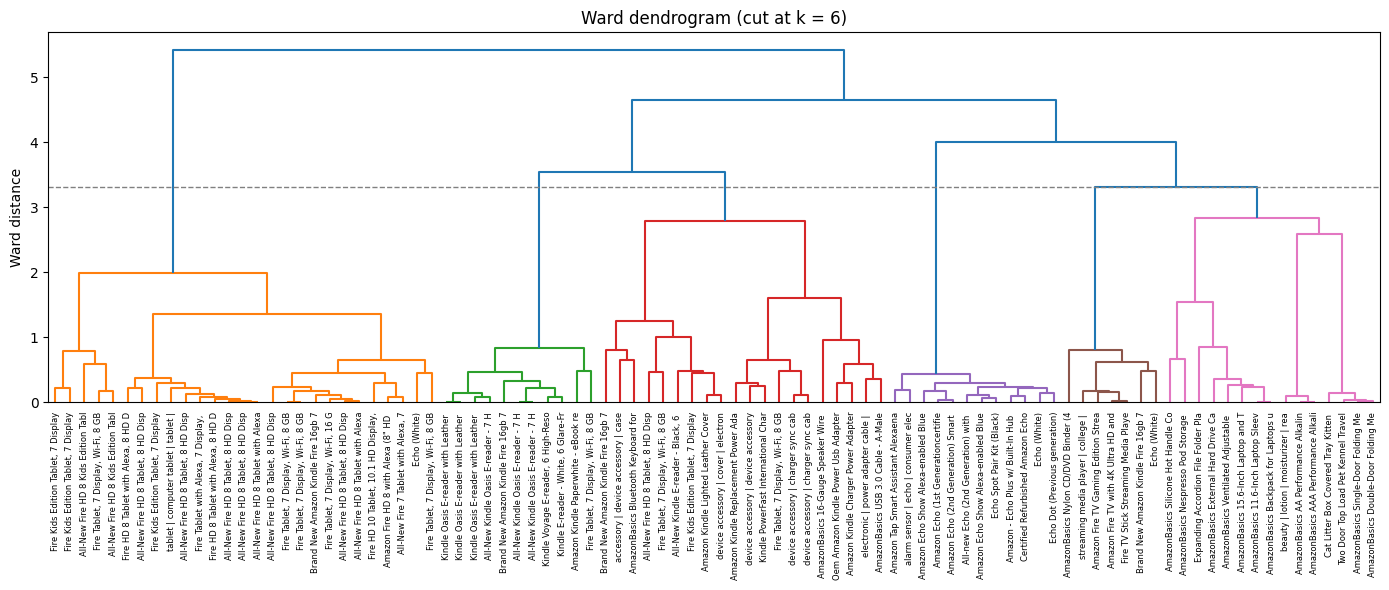

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram

agglo = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward")
products["agglo_cluster"] = agglo.fit_predict(X)
display(products["agglo_cluster"].value_counts().sort_index().rename("products"))

# Dendrogram: the same Ward merges; the colors show the cut at BEST_K clusters
Z = linkage(X, method="ward")
labels_short = products["name"].where(products["name"] != "", products["cat_text"]).str[:35].tolist()
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=labels_short, leaf_font_size=6, color_threshold=Z[-BEST_K + 1, 2])
plt.axhline(Z[-BEST_K + 1, 2], color="grey", linestyle="--", linewidth=1)
plt.title(f"Ward dendrogram (cut at k = {BEST_K})")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

# 9. Name the clusters

Each cluster gets a readable name. The names are assigned automatically, so they stay correct even if the cluster ids change (e.g. with a different `random_state` or library version):
1. Each candidate name has a few **keywords** from the vocabulary.
2. Each cluster's mean TF-IDF vector is scored against each keyword list.
3. The **Hungarian algorithm** (`linear_sum_assignment`) picks the one-to-one name assignment with the highest total score.

The top terms and products of each cluster are printed so the names can be checked.

In [16]:
from scipy.optimize import linear_sum_assignment

CATEGORY_KEYWORDS = {
    "E-readers & Kindle": ["ereader", "kindle", "ebook"],
    "Fire Tablets": ["fire tablet", "tablet", "kid tablet"],
    "Smart Speakers & Echo": ["smart speaker", "smart home", "speaker", "echo"],
    "Streaming & TV": ["fire tv", "streaming", "tv", "media"],
    "Chargers & Cables": ["power adapter", "charger", "cable", "adapter"],
    "Household, Office & Pets": ["household", "battery", "pet", "office", "bag"],
}
keyword_idx = {
    name: [vectorizer.vocabulary_[w] for w in words if w in vectorizer.vocabulary_]
    for name, words in CATEGORY_KEYWORDS.items()
}

def name_clusters(label_col):
    # Mean TF-IDF (before LSA) per cluster -> best one-to-one match with the keyword lists
    clusters = sorted(products[label_col].unique())
    centroids = np.vstack([np.asarray(X_tfidf[(products[label_col] == c).to_numpy()].mean(axis=0)).ravel() for c in clusters])
    names = list(keyword_idx)
    score = np.array([[centroids[i, keyword_idx[n]].sum() for n in names] for i in range(len(clusters))])
    rows, cols = linear_sum_assignment(-score)       # maximize total score
    return {clusters[r]: names[c] for r, c in zip(rows, cols)}, centroids

def describe(label_col, names, centroids):
    for c, name in sorted(names.items()):
        members = products[products[label_col] == c]
        top_terms = vocabulary[centroids[c].argsort()[::-1][:8]]
        shown = members["name"].where(members["name"] != "", "(no name) " + members["cat_text"].str[:40])
        print(f"\n---- {c}: {name}  ({len(members)} products, {members['n_reviews'].sum()} reviews) ----")
        print("Top terms:", ", ".join(top_terms))
        print("Products :", " | ".join(shown.str[:50].head(6)))

kmeans_names, kmeans_centroids = name_clusters("kmeans_cluster")
agglo_names, agglo_centroids = name_clusters("agglo_cluster")
products["kmeans_category"] = products["kmeans_cluster"].map(kmeans_names)
products["agglo_category"] = products["agglo_cluster"].map(agglo_names)

print("=============== K-MEANS ===============")
describe("kmeans_cluster", kmeans_names, kmeans_centroids)

=============== K-MEANS ===============

---- 0: Fire Tablets  (27 products, 29635 reviews) ----
Top terms: tablet, tablet tablet, display, tablet computer, computer tablet, computer, new, electronic tablet
Products : Echo (White) | Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Spe | Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, | Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Spe | Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Sp | Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB,

---- 1: E-readers & Kindle  (18 products, 5064 reviews) ----
Top terms: ereader, kindle, display, kindle ereader, tablet, ereader ereader, ereader accessory, cover
Products : All-New Kindle Oasis E-reader - 7 High-Resolution  | All-New Kindle Oasis E-reader - 7 High-Resolution  | Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 | Amazon Kindle Lighted Leather Cover | All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32  | (no name) device accessory | cover | electronic | 

---- 2: Household, Office 

In [17]:
print("=============== AGGLOMERATIVE ===============")
describe("agglo_cluster", agglo_names, agglo_centroids)

=============== AGGLOMERATIVE ===============

---- 0: Household, Office & Pets  (15 products, 12140 reviews) ----
Top terms: laptop, crate, supply, pet, beauty, dog, bag, cat
Products : AmazonBasics Silicone Hot Handle Cover/Holder - Re | AmazonBasics Single-Door Folding Metal Dog Crate - | AmazonBasics 11.6-Inch Laptop Sleeve | AmazonBasics AA Performance Alkaline Batteries (48 | (no name) beauty | lotion | moisturizer | ready me | AmazonBasics Backpack for Laptops up to 17-inches

---- 1: Fire Tablets  (27 products, 29635 reviews) ----
Top terms: tablet, tablet tablet, display, tablet computer, computer tablet, computer, new, electronic tablet
Products : Echo (White) | Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Spe | Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, | Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Spe | Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Sp | Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB,

---- 2: Chargers & Cables  (20 products, 625 reviews) -

# 10. Compare the two models

## 10.1 Scores and agreement
- **Silhouette / Davies-Bouldin / Calinski-Harabasz** measure cluster quality on the features (Calinski-Harabasz: higher is better).
- **ARI / NMI** measure how similar the two groupings are (1.0 = identical).
- The crosstab shows where the two models place products differently.

In [18]:
def scores(labels):
    return {
        "Silhouette (cosine)": silhouette_score(X, labels, metric="cosine"),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
    }

comparison = pd.DataFrame({
    "K-Means": scores(products["kmeans_cluster"]),
    "Agglomerative (Ward)": scores(products["agglo_cluster"]),
}).T
display(comparison.round(3))

print("ARI K-Means vs Agglomerative:", round(adjusted_rand_score(products["kmeans_cluster"], products["agglo_cluster"]), 3))
print("NMI K-Means vs Agglomerative:", round(normalized_mutual_info_score(products["kmeans_cluster"], products["agglo_cluster"]), 3))

display(pd.crosstab(products["kmeans_category"], products["agglo_category"],
                    rownames=["K-Means"], colnames=["Agglomerative"]))

,Silhouette (cosine),Davies-Bouldin,Calinski-Harabasz
K-Means,0.607,1.130,34.341
Agglomerative (Ward),0.596,1.148,33.352


ARI K-Means vs Agglomerative: 0.868
NMI K-Means vs Agglomerative: 0.921


Agglomerative,Chargers & Cables,E-readers & Kindle,Fire Tablets,"Household, Office & Pets",Smart Speakers & Echo,Streaming & TV
K-Means,,,,,,
Chargers & Cables,13,0,0,0,0,0
E-readers & Kindle,7,11,0,0,0,0
Fire Tablets,0,0,27,0,0,0
"Household, Office & Pets",0,0,0,15,0,0
Smart Speakers & Echo,0,0,0,0,12,0
Streaming & TV,0,0,0,0,0,7


In [19]:
# Products the two models put in different categories
disagree = products[products["kmeans_category"] != products["agglo_category"]]
print(f"{len(disagree)} of {len(products)} products differ ({disagree['n_reviews'].sum()} reviews)")
display(disagree[["name", "kmeans_category", "agglo_category", "n_reviews"]]
        .assign(name=lambda d: d["name"].where(d["name"] != "", "(no name)").str[:70]))

7 of 92 products differ (447 reviews)


,name,kmeans_category,agglo_category,n_reviews
id,,,,
AVpe9CMS1cnluZ0-aoC5,Amazon Kindle Lighted Leather Cover,E-readers & Kindle,Chargers & Cables,5
AVpfBEWcilAPnD_xTGb7,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Specia",E-readers & Kindle,Chargers & Cables,19
AVpf_znpilAPnD_xlvAF,(no name),E-readers & Kindle,Chargers & Cables,10
AVpg3q4RLJeJML43TxA_,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Cas",E-readers & Kindle,Chargers & Cables,6
AVpioXbb1cnluZ0-PImd,Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,E-readers & Kindle,Chargers & Cables,2
AVsRjfwAU2_QcyX9PHqe,"All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-",E-readers & Kindle,Chargers & Cables,402
AVzvXXxbvKc47QAVfRhy,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",E-readers & Kindle,Chargers & Cables,3


## 10.2 Category sizes

The models cluster products, but what matters downstream is how many **reviews** each category gets.

In [20]:
sizes = pd.concat({
    ("K-Means", "products"): products.groupby("kmeans_category").size(),
    ("K-Means", "reviews"): products.groupby("kmeans_category")["n_reviews"].sum(),
    ("Agglomerative", "products"): products.groupby("agglo_category").size(),
    ("Agglomerative", "reviews"): products.groupby("agglo_category")["n_reviews"].sum(),
}, axis=1).fillna(0).astype(int)
display(sizes)

K-Means         Agglomerative        
                         products reviews      products reviews
Chargers & Cables              13     178            20     625
E-readers & Kindle             18    5064            11    4617
Fire Tablets                   27   29635            27   29635
Household, Office & Pets       15   12140            15   12140
Smart Speakers & Echo          12    8737            12    8737
Streaming & TV                  7    5087             7    5087

## 10.3 Stability

A good clustering shouldn't change much when the data changes a little. Each model is refitted 50 times on a random **80% of the products**, and the result is compared (ARI) with the full-data clustering on the products both runs share. Higher and tighter is better.

,K-Means,Agglomerative (Ward)
mean,0.915,0.911
std,0.068,0.078
min,0.746,0.718


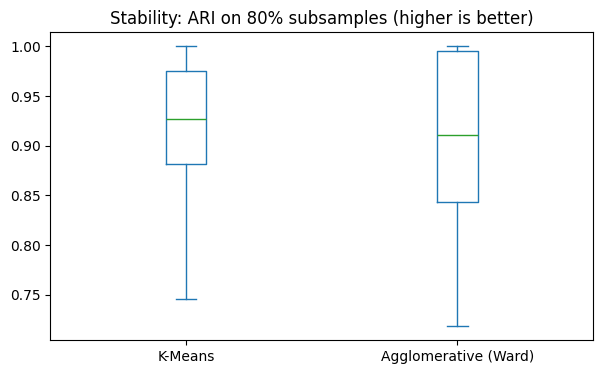

In [21]:
rng = np.random.default_rng(42)
stability = {"K-Means": [], "Agglomerative (Ward)": []}
for _ in range(50):
    idx = np.sort(rng.choice(len(X), size=int(0.8 * len(X)), replace=False))
    km_sub = KMeans(n_clusters=BEST_K, n_init=10, random_state=0).fit_predict(X[idx])
    ag_sub = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward").fit_predict(X[idx])
    stability["K-Means"].append(adjusted_rand_score(products["kmeans_cluster"].to_numpy()[idx], km_sub))
    stability["Agglomerative (Ward)"].append(adjusted_rand_score(products["agglo_cluster"].to_numpy()[idx], ag_sub))

stability = pd.DataFrame(stability)
display(stability.describe().loc[["mean", "std", "min"]].round(3))

stability.plot(kind="box", title="Stability: ARI on 80% subsamples (higher is better)", figsize=(7, 4))
plt.show()

## 10.4 Visual comparison

The 10-dimensional LSA vectors are projected to 2D with PCA. Each point is a product, sized by its number of reviews.

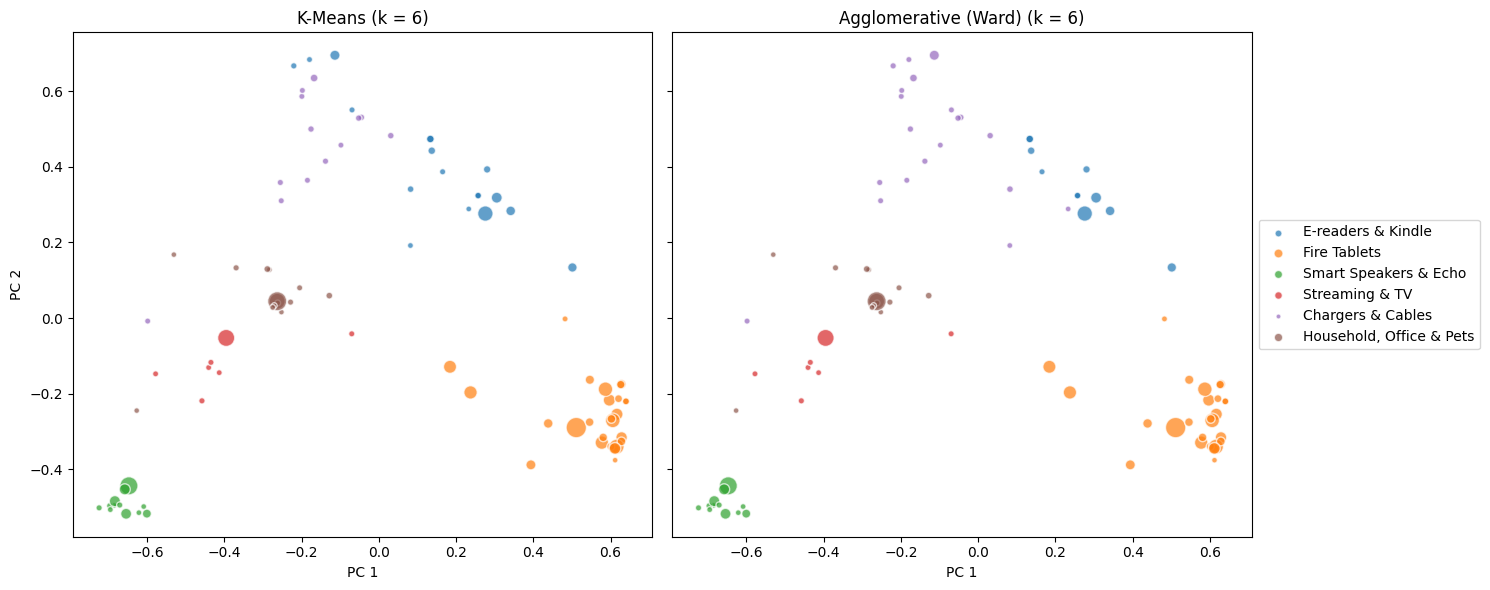

In [22]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(X)
category_names = list(CATEGORY_KEYWORDS)
colors = dict(zip(category_names, plt.cm.tab10.colors))
point_size = 15 + 200 * np.sqrt(products["n_reviews"] / products["n_reviews"].max())

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for ax, col, title in zip(axes, ["kmeans_category", "agglo_category"], ["K-Means", "Agglomerative (Ward)"]):
    for name in category_names:
        m = (products[col] == name).to_numpy()
        ax.scatter(coords[m, 0], coords[m, 1], s=point_size[m], color=colors[name], alpha=0.7, label=name, edgecolor="white")
    ax.set_title(f"{title} (k = {BEST_K})")
    ax.set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5), markerscale=0.6)
plt.tight_layout()
plt.show()

# 11. Label every review and save

Each review inherits the categories of its product. The result is saved to `datasets/clustered_reviews.csv` for the next tasks.

In [25]:
category_cols = ["kmeans_cluster", "kmeans_category"]
reviews_labeled = reviews.merge(products[["name"] + category_cols].rename(columns={"name": "product_name"}),
                                left_on="id", right_index=True, how="left")

assert reviews_labeled["kmeans_category"].notna().all()
display(reviews_labeled[["product_name", "kmeans_category", "reviews.title"]].sample(8, random_state=42))

keep = ["id", "product_name", "name", "brand", "categories", "source",
        "reviews.rating", "reviews.title", "reviews.text"] + category_cols
reviews_labeled[keep].to_csv("datasets/clustered_reviews.csv", index=False)
print("Saved", reviews_labeled.shape[0], "reviews to datasets/clustered_reviews.csv")

,product_name,kmeans_category,reviews.title
38223,AmazonBasics AAA Performance Alkaline Batteries (36 Count),"Household, Office & Pets",Best value you'll find!
55581,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",Fire Tablets,Great Packaging Good Functioning
8854,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",Fire Tablets,Great tablet
28473,Echo (White),Smart Speakers & Echo,So far it's been fantastic!!
8489,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",Fire Tablets,Great tablet for beginner
41717,AmazonBasics AAA Performance Alkaline Batteries (36 Count),"Household, Office & Pets",Four Stars
38550,AmazonBasics AAA Performance Alkaline Batteries (36 Count),"Household, Office & Pets",Don't buy Any other batteries it's a waste of money
53073,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Pink Kid-Proof Case",Fire Tablets,Nice


Saved 60841 reviews to datasets/clustered_reviews.csv


# 12. Categorize a new product

A new product goes through the same cleaning, vocabulary, TF-IDF and LSA steps. K-Means assigns it to the nearest center. Agglomerative clustering has no `predict`, so the new product goes to the cluster with the nearest mean vector (nearest centroid).

In [24]:
from sklearn.neighbors import NearestCentroid

agglo_predictor = NearestCentroid().fit(X, products["agglo_cluster"])

def categorize(categories, name=""):
    tfidf = normalize(vectorizer.transform([categories_to_text(split_tags(categories))])
                      + NAME_WEIGHT * vectorizer.transform([normalize_text(name)]))
    x = normalize(svd.transform(tfidf))
    return kmeans_names[kmeans.predict(x)[0]], agglo_names[agglo_predictor.predict(x)[0]]

new_products = [
    ("Electronics,eBook Readers,Kindle E-readers", "Kindle Paperwhite 2024"),
    ("Smart Home,Smart Speakers,Voice Assistants", "Echo Pop"),
    ("Streaming Media Players,TV & Video", "Fire TV Stick 4K Max"),
    ("Computers & Tablets,Tablets,Kids' Tablets", "Fire HD 10 Kids"),
    ("Power Adapters & Cables,Chargers & Sync Cables", "USB-C charger"),
    ("Health & Household,Batteries,Household Batteries", "AmazonBasics 9V batteries"),
]
display(pd.DataFrame(
    [(name, cats, *categorize(cats, name)) for cats, name in new_products],
    columns=["name", "categories", "K-Means", "Agglomerative"],
))

,name,categories,K-Means,Agglomerative
0,Kindle Paperwhite 2024,"Electronics,eBook Readers,Kindle E-readers",E-readers & Kindle,E-readers & Kindle
1,Echo Pop,"Smart Home,Smart Speakers,Voice Assistants",Smart Speakers & Echo,Smart Speakers & Echo
2,Fire TV Stick 4K Max,"Streaming Media Players,TV & Video",Streaming & TV,Streaming & TV
3,Fire HD 10 Kids,"Computers & Tablets,Tablets,Kids' Tablets",Fire Tablets,Fire Tablets
4,USB-C charger,"Power Adapters & Cables,Chargers & Sync Cables",Chargers & Cables,Chargers & Cables
5,AmazonBasics 9V batteries,"Health & Household,Batteries,Household Batteries","Household, Office & Pets","Household, Office & Pets"


# 13. Conclusions

**Data:** the three files hold 67,992 rows. After removing 7,151 reviews duplicated across files, 60,841 reviews remain for **92 products**. Clustering the products (not the reviews) gives every product equal weight and labels every review consistently.

**Features:** cleaned category tags → vocabulary of ~390 unigrams/bigrams → TF-IDF (+ name projected onto the same vocabulary at weight 0.5) → 10 LSA components.

**Both models find the same 6 meta-categories:**

| Category | Reviews | Typical products |
|---|---|---|
| Fire Tablets | ~29,600 | Fire 7, Fire HD 8/10, Fire Kids Edition |
| Household, Office & Pets | ~12,100 | AmazonBasics batteries, laptop bags, pet crates |
| Smart Speakers & Echo | ~8,700 | Echo, Echo Dot, Echo Show, Amazon Tap |
| Streaming & TV | ~5,100 | Fire TV, Fire TV Stick |
| E-readers & Kindle | ~4,600–5,100 | Kindle Paperwhite, Oasis, Voyage |
| Chargers & Cables | ~200–600 | power adapters, USB cables |

**Comparison:**

| | K-Means | Agglomerative (Ward) |
|---|---|---|
| Silhouette (higher is better) | **0.607** | 0.596 |
| Davies-Bouldin (lower is better) | **1.130** | 1.148 |
| Calinski-Harabasz (higher is better) | **34.3** | 33.4 |
| Stability (mean ARI on 80% subsamples) | **0.915** | 0.911 |

- The models agree on **85 of 92 products** (ARI 0.87, NMI 0.92). Four of the six categories are identical.
- All 7 disagreements are between *E-readers & Kindle* and *Chargers & Cables*. Agglomerative builds a broader "Kindle accessories" cluster that also takes the *All-New Kindle E-reader* (402 reviews), which is a real e-reader. K-Means keeps it with the e-readers.
- **K-Means is the recommended model:** it scores slightly better on every metric, it places the disputed e-reader correctly, and it can `predict` new products directly. Agglomerative is useful as a cross-check, and its dendrogram shows how the categories are nested.

**Limitations:**
- `name` is unreliable in `1429_1.csv` (one name is attached to up to 7 different ids), so it is only used as a secondary signal.
- "Household, Office & Pets" is a catch-all for the AmazonBasics products. With k = 7 or more it would split further, but that goes beyond the 4–6 category target.